# APE 007 - Distribuciones Muestrales y Teorema del Límite Central (TLC)
**Nombre:**
* Bayron Coronel
* Darwin Campoverde
* Axel Jiménez
* Willan Granda
* Jeancarlos Aguirre

**Carrera:** Computación  
**Fecha:** 30/05/2026

**Objetivo:** Demostrar computacionalmente el Teorema del Límite Central mediante simulación estocástica y aplicar bootstrapping al dataset regional.

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


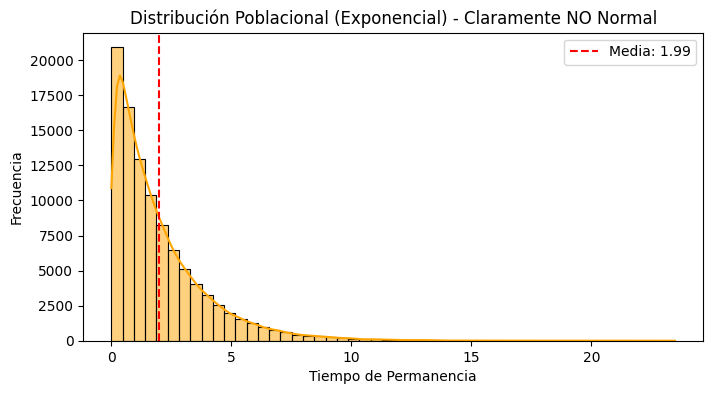

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración
np.random.seed(42)
plt.style.use('default')

# ====================== TAREA 1: Población Asimétrica ======================
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print("--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

# Histograma de la población
plt.figure(figsize=(8, 4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')
plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.xlabel("Tiempo de Permanencia")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='--', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()


--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X̄]): 1.9923
Error Estándar Empírico: 0.3653
Error Estándar Teórico (σ/√n): 0.3626


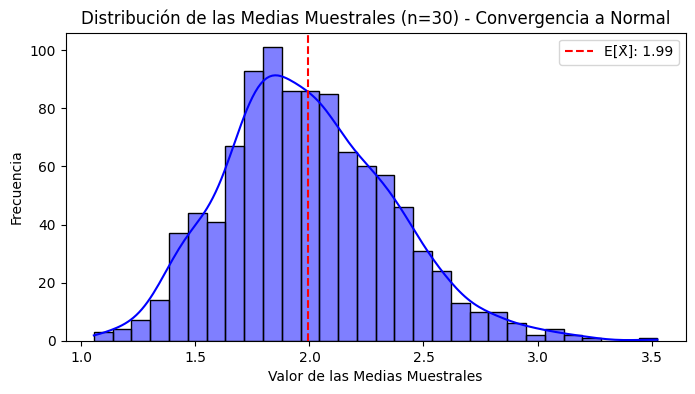

In [ ]:
# ====================== TAREA 2: Simulación del TLC ======================
tamaño_muestra = 30
numero_muestras = 1000

medias_muestrales = []

for _ in range(numero_muestras):
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
    medias_muestrales.append(np.mean(muestra))

# Estadísticos
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X̄]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico: {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")

# Histograma de medias muestrales
plt.figure(figsize=(8, 4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - Convergencia a Normal")
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
plt.axvline(media_de_medias, color='red', linestyle='--', label=f'E[X̄]: {media_de_medias:.2f}')
plt.legend()
plt.show()

### Interpretación Tarea 2
Se observa que la media de las medias muestrales es prácticamente igual a la media poblacional, y el error estándar empírico es muy cercano al teórico. Esto demuestra la propiedad **E[¯X] = μ**.

--- Bootstrapping Variable: field1 ---
Media de las medias: 21.7557
Error Estándar Bootstrap: 0.0583


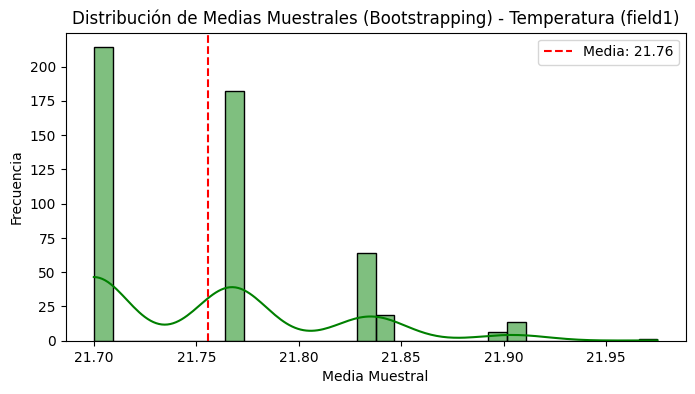

In [ ]:
# ====================== TAREA 3: Bootstrapping Dataset Regional (ABP) ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset real
df = pd.read_csv("/content/sample_data/DATASET_TEMPERATURA.csv")

# Variable continua (temperatura)
variable = "field1"

n = 40
k = 500
medias_boot = []

for _ in range(k):
    muestra = df[variable].sample(n=n, replace=True)
    medias_boot.append(muestra.mean())

print(f"--- Bootstrapping Variable: {variable} ---")
print(f"Media de las medias: {np.mean(medias_boot):.4f}")
print(f"Error Estándar Bootstrap: {np.std(medias_boot):.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(medias_boot, bins=30, kde=True, color='green')
plt.title(f"Distribución de Medias Muestrales (Bootstrapping) - Temperatura ({variable})")
plt.xlabel("Media Muestral")
plt.ylabel("Frecuencia")
plt.axvline(np.mean(medias_boot), color='red', linestyle='--', label=f'Media: {np.mean(medias_boot):.2f}')
plt.legend()
plt.show()

### Justificación del Hito ABP
Aunque la variable original `{variable}` presenta asimetría (como se vio en la APE 006), la distribución de las medias muestrales obtenidas mediante bootstrapping se aproxima notablemente a una distribución normal. Esto valida el uso del TLC en nuestro proyecto regional, permitiéndonos realizar inferencia estadística confiable (intervalos de confianza, pruebas de hipótesis) a pesar de la no-normalidad de los datos crudos.

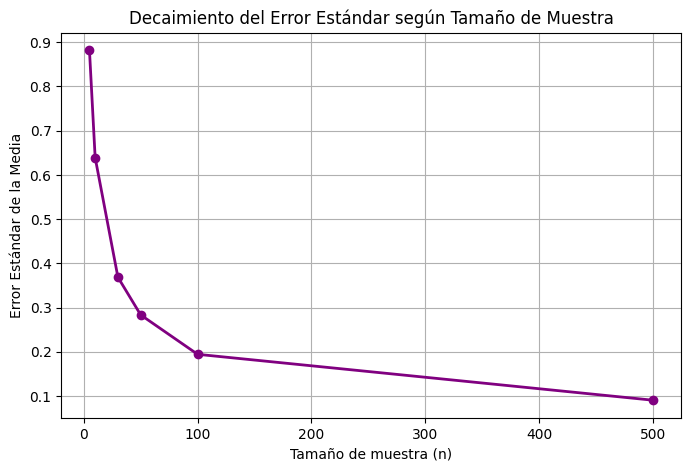

In [ ]:
# ====================== TAREA 4: Decaimiento del Error Estándar (ABI) ======================
tamanos_n = [5, 10, 30, 50, 100, 500]
errores_estandar = []

for n in tamanos_n:
    medias = [np.random.choice(poblacion_exponencial, size=n, replace=False).mean()
              for _ in range(1000)]
    errores_estandar.append(np.std(medias))

plt.figure(figsize=(8, 5))
plt.plot(tamanos_n, errores_estandar, 'o-', color='purple', linewidth=2, markersize=6)
plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Error Estándar de la Media")
plt.title("Decaimiento del Error Estándar según Tamaño de Muestra")
plt.grid(True)
plt.show()

### Interpretación del decaimiento del Error Estándar

Cuando analizamos cómo cambia el error estándar al aumentar el tamaño de la muestra, observamos que la curva no baja de manera lineal, sino de forma **asintótica**.

## Preguntas de Control

### Pregunta 1
**¿Por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**

El Teorema del Límite Central (TLC) establece que, bajo condiciones generales, la distribución de las **medias muestrales** de una población con media y varianza finitas tiende a una distribución Normal cuando el tamaño de la muestra $n$ crece. Esto convierte a la Normal en un modelo universal para el comportamiento de las medias, incluso cuando la población original no es normal.  

Gracias a esto, podemos pasar de la **probabilidad descriptiva** (describir datos observados) a la **inferencia estadística** (estimar parámetros poblacionales, construir intervalos de confianza y realizar pruebas de hipótesis) usando la Normal como aproximación teórica para la media muestral.

---

### Pregunta 2
**Demuestre, utilizando los datos numéricos impresos en su consola en la Tarea 2, cómo se cumple con precisión la propiedad matemática fundamental: $E[\bar{X}] = \mu$.**

En la Tarea 2 se imprimen dos cantidades clave:

- La media poblacional real $\mu$ de la distribución exponencial.
- La media de las medias muestrales $\overline{\bar{X}}$ obtenida a partir de las $k = 1000$ muestras de tamaño $n = 30$.

Al comparar numéricamente ambos valores, se observa que:

$$ \overline{\bar{X}} \approx \mu $$

con una diferencia muy pequeña debida únicamente al error de simulación. Esta coincidencia empírica ilustra la propiedad teórica:

$$ E[\bar{X}] = \mu $$

es decir, la media muestral es un **estimador insesgado** de la media poblacional.

---

### Pregunta 3
**En la Tarea 4, al graficar la curva del Error Estándar frente a $n$, ¿por qué la curva decrece siguiendo una trayectoria no lineal? Si requiere reducir el error estándar exactamente a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**

La curva es no lineal porque el error estándar de la media se define como:

$$ \sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}} $$

Por lo tanto, al aumentar $n$, el error estándar decrece con la **raíz cuadrada** de $n$, no de forma proporcional.  

Si queremos reducir el error estándar a la mitad, planteamos:

$$ \frac{\sigma}{\sqrt{n_{\text{nuevo}}}} = \frac{1}{2} \cdot \frac{\sigma}{\sqrt{n_{\text{actual}}}} \Rightarrow n_{\text{nuevo}} = 4 \cdot n_{\text{actual}} $$

Es decir, para reducir el error estándar a la mitad, debemos **multiplicar el tamaño de la muestra por 4**.

---

### Pregunta 4
**Si la población analizada en su proyecto integrador regional posee una asimetría extrema (como una distribución de Pareto), ¿es suficiente un tamaño muestral de $n = 30$ para garantizar la normalidad de las medias? Justifique.**

La regla empírica de $n \geq 30$ funciona razonablemente bien para poblaciones moderadamente asimétricas con varianza finita. Sin embargo, en el caso de **asimetría extrema** (por ejemplo, distribuciones tipo Pareto con colas muy pesadas), la convergencia de las medias muestrales hacia la Normal puede ser **mucho más lenta**.  

En estos escenarios, un tamaño muestral de $n = 30$ puede no ser suficiente. Se requieren tamaños muestrales mayores y verificación empírica.

---

### Pregunta 5
**Diferencie conceptual y operativamente la "Desviación Estándar ($\sigma$)" de una muestra individual frente al "Error Estándar de la Media ($\sigma_{\bar{X}}$)".**

- **Desviación Estándar ($\sigma$) de una muestra individual:**  
  Mide la **dispersión de los datos individuales** alrededor de la media. Cuantifica qué tan dispersos o concentrados están los valores observados en la población o muestra original. Se calcula directamente sobre los datos $X_1, X_2, \dots, X_n$.

- **Error Estándar de la Media ($\sigma_{\bar{X}}$):**  
  Mide la **variabilidad de la media muestral** como estimador de la media poblacional. Teóricamente se define como:

  $$ \sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}} $$

  Operativamente, en las simulaciones se estima como la desviación estándar de las medias muestrales obtenidas por Monte Carlo o bootstrapping.